In [8]:
import numpy as np
import pysindy as ps

import sys, os
sys.path.insert(0, os.getcwd())
from ode_systems import SYSTEMS, list_systems


from ode_utils import (
    generate_data, simulate_from_coefficients,
    plot_phase_portrait, plot_trajectories, plot_coefficient_comparison,
    plot_noise_sweep, relative_l2_error, coefficient_error, precision_recall,
    print_metrics, metrics_dict, build_true_coef_matrix,
    print_discovered_equations,
)

In [9]:
# System selection — change this key to switch problems.
# Run list_systems() to see all available options.
SYSTEM_KEY = "lorenz"
SYSTEM     = SYSTEMS[SYSTEM_KEY]

# Initial condition (must have SYSTEM.n_dim entries)
X0 = [-8.0, 8.0, 27.0]

# Integration
T_SPAN      = (0.0, 20.0)   # (t_start, t_end)
DT          = 0.01           # timestep
NOISE_LEVEL = 0.00           # additive noise as fraction of signal RMS
SEED        = 42

# Candidate library
POLY_DEGREE       = 2        # polynomial degree
INCLUDE_SINE      = False    # add Fourier terms (useful for oscillators)
CUSTOM_LIBRARY_FN = None     # set to a callable () -> PySINDy library, or None

# Optimiser (STLSQ)
THRESHOLD = 0.05   # sparsity threshold
ALPHA     = 0.05   # ridge regularisation
MAX_ITER  = 20

# Differentiation
# Options: 'spline' | 'smoothed_finite_difference' | 'finite_difference'
DIFF_METHOD = "spline"
SPLINE_S    = 1e-3   # smoothing factor (spline only)

# Evaluation
T_EVAL_END         = 10.0   # trajectory comparison window
SWEEP_NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1, 0.2]

RESULTS_FILE = f"results/sindy_{SYSTEM_KEY}_results.pkl"

In [10]:
t, X = generate_data(SYSTEM, X0, T_SPAN, DT,
                     noise_level=NOISE_LEVEL, seed=SEED)
print(X)

[[-8.00000000e+00  8.00000000e+00  2.70000000e+01]
 [-6.48640305e+00  7.80317052e+00  2.57255226e+01]
 [-5.13801768e+00  7.56258900e+00  2.46088107e+01]
 ...
 [ 9.55398203e-03  2.74242738e-01  1.56306754e+01]
 [ 3.47204549e-02  2.74321477e-01  1.52194264e+01]
 [ 5.76547823e-02  2.77589358e-01  1.48190649e+01]]


In [11]:
n = len(t)
x1 = X[0:int(n/2),:]
x2 = X[int(n/2):,:]
delta_12 = x1-x2
r12 = np.linalg.norm(delta_12,axis=1)[:,np.newaxis]
hat = delta_12 / r12
u = np.concatenate([r12,hat],axis=1)

# print(x1)
# print(x2)
# print(x1 - x2)
# print(x1.shape)
# print(x2.shape)
# print(delta_12.shape)
# print(np.linalg.norm(delta_12,axis=1))

print(u)



poly_lib = ps.PolynomialLibrary(degree=4)
vectorHat_lib = ps.IdentityLibrary()
lib = ps.GeneralizedLibrary(
    [poly_lib,vectorHat_lib],
    [[1,1]],
    [[3],[4,5,6]]
)


[[18.15739123 -0.8908823  -0.23033047  0.39150556]
 [16.72186015 -0.90119719 -0.29381371  0.31861753]
 [15.65759825 -0.90305327 -0.36192141  0.23131727]
 ...
 [12.85762786  0.54731661  0.79881148  0.24968931]
 [13.6558023   0.53978461  0.79194723  0.28539823]
 [14.50188511  0.53270671  0.78330561  0.32039956]]


In [12]:
optimizer = ps.STLSQ(threshold=THRESHOLD, alpha=ALPHA, max_iter=MAX_ITER)
diff = ps.differentiation.FiniteDifference()
model = ps.SINDy(
    feature_library=lib,
    optimizer=optimizer,
    differentiation_method=diff,
)
model.fit(
    X[0:int(n/2),:],
    t=DT,
    u=u
)
model.get_feature_names()

['1',
 'u0',
 'u0^2',
 'u0^3',
 'u0^4',
 'u1',
 'u2',
 'u3',
 '1 u1',
 '1 u2',
 '1 u3',
 'u0 u1',
 'u0 u2',
 'u0 u3',
 'u0^2 u1',
 'u0^2 u2',
 'u0^2 u3',
 'u0^3 u1',
 'u0^3 u2',
 'u0^3 u3',
 'u0^4 u1',
 'u0^4 u2',
 'u0^4 u3']

In [13]:
from scipy.io import loadmat
data = loadmat("../../3body.mat")
# print(data)
# print(data["traj_3body"][0][1][1])

nTraj = len(data["traj_3body"][0])
x = data["traj_3body"][0][0][1][0:3,:]
for i in range(1,nTraj):
    print(i)
    x = np.concatenate([x,data["traj_3body"][0][i][1][0:3,:]],axis=0)
print(x.shape)
x = x.T
print(x.shape)
t = data["traj_3body"][0][0][0][:].flatten()

print(t-data["traj_3body"][0][1][0][:].flatten())
print(t.shape)
# t = np.tile(t,[1,7*nTraj])
print(nTraj)

1
2
(9, 100001)
(100001, 9)
[0. 0. 0. ... 0. 0. 0.]
(100001,)
3


In [14]:
x1 = x[:,0:3]
x2 = x[:,3:6]
x3 = x[:,6:9]

delta12 = x1-x2
r12 = np.linalg.norm(delta12,axis=1)[:,np.newaxis]
r12 = np.pow(r12,-1)
hat12 = delta12 * r12

delta13 = x1-x3
r13 = np.linalg.norm(delta13,axis=1)[:,np.newaxis]
r13 = np.pow(r13,-1)
hat13 = delta13 * r13

delta23 = x2-x3
r23 = np.linalg.norm(delta23,axis=1)[:,np.newaxis]
r23 = np.pow(r23,-1)
hat23 = delta23 * r23

u = np.concatenate([r12,hat12,r13,hat13,r23,hat23],axis=1)
print(u.shape)
# print(u)
print(u[183,:])

nvars = 3 * nTraj

poly_lib = ps.PolynomialLibrary(degree=2)
vectorHat_lib = ps.IdentityLibrary()
lib = ps.GeneralizedLibrary(
    [poly_lib,vectorHat_lib,poly_lib,vectorHat_lib,poly_lib,vectorHat_lib],
    [[1,1,0,0,0,0],[0,0,1,1,0,0],[0,0,0,0,1,1]],
    [[9],[10,11,12],[13],[14,15,16],[17],[18,19,20]]
)



# print(delta12.shape)
# r12 = np.linalg.norm(delta12,axis=0)[np.newaxis,:]
# print(r12.shape)
# hat = delta12 / r12
# print(hat)


(100001, 12)
[ 0.57388269 -0.58435864  0.57377092 -0.57385705  0.35196548 -0.71030515
 -0.00644074 -0.70386441  0.57392084 -0.57383806 -0.58431145 -0.57383796]


In [15]:
optimizer = ps.STLSQ(threshold=THRESHOLD, alpha=ALPHA, max_iter=200)
diff = ps.differentiation.FiniteDifference(
    order=4,
    d=2,
    axis=0)
model = ps.SINDy(
    feature_library=lib,
    optimizer=ps.optimizers.STLSQ(alpha=0.005),
    differentiation_method=diff,
)
print(x.shape)
print(t.shape)
print(u.shape)
model.fit(
    x,
    t=t,
    u=u
)
print(model.get_feature_names())
model.print()
model.score(x=x,t=t,u=u)

(100001, 9)
(100001,)
(100001, 12)
['1', 'u0', 'u0^2', 'u1', 'u2', 'u3', '1', 'u4', 'u4^2', 'u5', 'u6', 'u7', '1', 'u8', 'u8^2', 'u9', 'u10', 'u11', '1 u1', '1 u2', '1 u3', 'u0 u1', 'u0 u2', 'u0 u3', 'u0^2 u1', 'u0^2 u2', 'u0^2 u3', '1 u5', '1 u6', '1 u7', 'u4 u5', 'u4 u6', 'u4 u7', 'u4^2 u5', 'u4^2 u6', 'u4^2 u7', '1 u9', '1 u10', '1 u11', 'u8 u9', 'u8 u10', 'u8 u11', 'u8^2 u9', 'u8^2 u10', 'u8^2 u11']
(x0)' = -2.004 u0^2 u1 + -2.997 u4^2 u5
(x1)' = -2.003 u0^2 u2 + -2.998 u4^2 u6
(x2)' = -2.000 u0^2 u3 + -2.998 u4^2 u7
(x3)' =  1.001 u0^2 u1 + -2.998 u8^2 u9
(x4)' =  1.002 u0^2 u2 + -2.999 u8^2 u10
(x5)' =  1.001 u0^2 u3 + -2.998 u8^2 u11
(x6)' =  0.999 u4^2 u5 +  1.999 u8^2 u9
(x7)' =  0.999 u4^2 u6 +  1.999 u8^2 u10
(x8)' =  1.000 u4^2 u7 +  1.999 u8^2 u11


0.9851751554580925

In [16]:
# Trying a new approach where we consider only the x-vector component\
poly_lib = ps.PolynomialLibrary(
    degree=6,
    include_bias=False)
vectorHat_lib = ps.IdentityLibrary()
tensorProd_lib = ps.TensoredLibrary(
    [poly_lib,vectorHat_lib],
    [[0],[1]]
)

print(u.shape)
x_xhat_traj1 = x[:,0]
u_xhat_traj1 = u[:,0:6]
lib = ps.GeneralizedLibrary(
    [poly_lib,vectorHat_lib,poly_lib,vectorHat_lib],
    [[1,1,0,0],[0,0,1,1]],
    [[1],[2],[5],[6]]
)

lib = ps.GeneralizedLibrary(
    [tensorProd_lib,tensorProd_lib],
    None,
    [[1,2],[5,6]]
)



print(x_xhat_traj1.shape)


# # 9, 13, 17 are r12, r13, r23 respectively
# # 10, 14, 18 are the x-hat components of each of those vectors
# # will probably need to zero out all the non-x-component pieces of u; for now, just toss em in
# lib = ps.GeneralizedLibrary(
#     [poly_lib,vectorHat_lib,poly_lib,vectorHat_lib,poly_lib,vectorHat_lib],
#     [[1,1,0,0,0,0],[0,0,1,1,0,0],[0,0,0,0,1,1]],
#     [[9],[10],[13],[14],[17],[18]]
# )
optimizer = ps.STLSQ(threshold=THRESHOLD, alpha=ALPHA, max_iter=200)
diff = ps.differentiation.FiniteDifference(
    order=4,
    d=2,
    axis=0)
model = ps.SINDy(
    feature_library=lib,
    optimizer=ps.optimizers.STLSQ(alpha=0.05),
    differentiation_method=diff,
)

print(x_xhat_traj1.shape)
print(t.shape)
print(u_xhat_traj1.shape)

model.fit(
    x_xhat_traj1,
    t=t,
    u=u_xhat_traj1,
    feature_names=['x','r12','x12','y12','z12','r23','x23','y23','z23']
)
print(model.get_feature_names())
model.print()
model.score(x=x_xhat_traj1,t=t,u=u_xhat_traj1)


(100001, 12)
(100001,)
(100001,)
(100001,)
(100001, 6)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


['r12 x12', 'r12^2 x12', 'r12^3 x12', 'r12^4 x12', 'r12^5 x12', 'r12^6 x12', 'r23 x23', 'r23^2 x23', 'r23^3 x23', 'r23^4 x23', 'r23^5 x23', 'r23^6 x23']
(x)' = -2.004 r12^2 x12 + -2.997 r23^2 x23


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


0.9784072516870285

In [17]:
# Trying a new approach where we consider only the x-vector component\
poly_lib = ps.PolynomialLibrary(
    degree=4,
    include_bias=False)
vectorHat_lib = ps.IdentityLibrary()
tensorProd_lib = ps.TensoredLibrary(
    [poly_lib,vectorHat_lib],
    [[0],[1]]
)
x_xhat_traj2 = x[:,0]
u_xhat_traj2 = np.concatenate([u[:,0:3],u[:,3:6]],axis=1)
lib = ps.GeneralizedLibrary(
    [tensorProd_lib,tensorProd_lib],
    None,
    [[1,2],[5,6]]
)

diff = ps.differentiation.FiniteDifference(
    order=4,
    d=2,
    axis=0)
model = ps.SINDy(
    feature_library=lib,
    optimizer=ps.optimizers.STLSQ(alpha=0.1),
    differentiation_method=diff,
)


model.fit(
    x_xhat_traj2,
    t=t,
    u=u_xhat_traj2,
    feature_names=['x','r12','x12','y12','z12','r23','x23','y23','z23']
)
print(model.get_feature_names())
model.print()
model.score(x=x_xhat_traj1,t=t,u=u_xhat_traj1)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


['r12 x12', 'r12^2 x12', 'r12^3 x12', 'r12^4 x12', 'r23 x23', 'r23^2 x23', 'r23^3 x23', 'r23^4 x23']
(x)' = -2.004 r12^2 x12 + -2.997 r23^2 x23


0.9784072516870285

In [18]:
import run_centralforce_sindy

run_centralforce_sindy.run_centralforce_sindy("../../3body.mat")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


(x0)' = -2.002 u0^2 u1 + -2.998 u2^2 u3
0.9896400416067002


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


(x0)' = -1.001 u0^2 u1 + -2.998 u2^2 u3
0.9968531048031111


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


(x0)' = -0.999 u0^2 u1 + -1.999 u2^2 u3
0.9966751185013444


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


In [19]:
import run_centralforce_sindy

run_centralforce_sindy.run_centralforce_sindy("../../2body.mat")

(x0)' = -1.997 u0^2 u1
0.9935819301376811
(x0)' = -0.998 u0^2 u1
0.9935819301342047


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 ax

In [20]:
import run_centralforce_sindy

run_centralforce_sindy.run_centralforce_sindy("../../4body.mat")

(x0)' = -1.995 u0^2 u1 + -2.995 u2^2 u3 + -4.004 u4^2 u5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 ax

0.9984266073819742
(x0)' = -0.999 u0^2 u1 + -0.001 u2 u3 + -2.994 u2^2 u3 + -4.002 u4^2 u5
0.9974672099591807
(x0)' = -0.999 u0^2 u1 + -1.983 u2^2 u3 + -3.999 u4^2 u5
0.9993617714556978
(x0)' = -0.998 u0^2 u1 + -2.002 u2^2 u3 + -2.999 u4^2 u5
0.9995139649800916


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


In [21]:
import get_planetary_data

# print(get_planetary_data.extract_planetary_data("mars",100,1/10))

get_planetary_data.extract_multiplanetary_data(100,1/10,True,"fourPlanets_100years_10per.pickle")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 970 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3

array([[-3.06664368e-03, -5.12880054e-03, -2.08015833e-03, ...,
        -1.69689854e+00,  4.51014826e+00,  1.97452098e+00],
       [-2.80581563e-03, -5.11518915e-03, -2.07972374e-03, ...,
        -1.95850740e+00,  4.43093661e+00,  1.94693768e+00],
       [-2.54797290e-03, -5.08955002e-03, -2.07418407e-03, ...,
        -2.21468173e+00,  4.33943306e+00,  1.91395344e+00],
       ...,
       [ 6.02794042e-03,  3.64995265e-03,  1.37016618e-03, ...,
        -2.05123884e+00, -4.55247102e+00, -1.90115617e+00],
       [ 5.81748368e-03,  3.77811375e-03,  1.42886731e-03, ...,
        -1.79748205e+00, -4.62984814e+00, -1.94047518e+00],
       [ 5.60273776e-03,  3.89757223e-03,  1.48398894e-03, ...,
        -1.53902644e+00, -4.69517987e+00, -1.97474636e+00]],
      shape=(1000, 12))

In [22]:
import pickle
with open("fourPlanets_100years_10per.pickle",'rb') as f:
    data = pickle.load(f)

print(data)
print(data.shape)

[[-3.06664368e-03 -5.12880054e-03 -2.08015833e-03 ... -1.69689854e+00
   4.51014826e+00  1.97452098e+00]
 [-2.80581563e-03 -5.11518915e-03 -2.07972374e-03 ... -1.95850740e+00
   4.43093661e+00  1.94693768e+00]
 [-2.54797290e-03 -5.08955002e-03 -2.07418407e-03 ... -2.21468173e+00
   4.33943306e+00  1.91395344e+00]
 ...
 [ 6.02794042e-03  3.64995265e-03  1.37016618e-03 ... -2.05123884e+00
  -4.55247102e+00 -1.90115617e+00]
 [ 5.81748368e-03  3.77811375e-03  1.42886731e-03 ... -1.79748205e+00
  -4.62984814e+00 -1.94047518e+00]
 [ 5.60273776e-03  3.89757223e-03  1.48398894e-03 ... -1.53902644e+00
  -4.69517987e+00 -1.97474636e+00]]
(1000, 12)


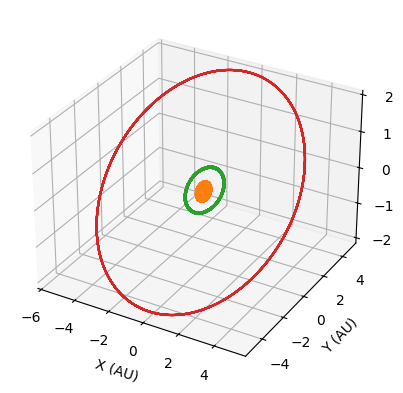

In [23]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
nTraj = round(data.shape[1]/3)
for i in range(nTraj):
    ax.plot(data[:,(3*i)+0],data[:,(3*i)+1],data[:,(3*i)+2])

ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")
ax.set_zlabel("Z (AU)")
plt.show()

In [1]:
import run_centralforce_sindy
import get_planetary_data

# get_planetary_data.extract_multiplanetary_data(5,1/365,True,"fourPlanets_5years_365per.pickle")
run_centralforce_sindy.run_centralforce_sindy("fourPlanets_5years_365per.pickle",fileFormat="pickle")

[ 0.33732769 -1.26285052 -0.58814818]
[ 0.35143728 -1.25852274 -0.58654365] AU
<SkyCoord (GCRS: obstime=2026-01-01 00:00:00.000, obsgeoloc=(0., 0., 0.) m, obsgeovel=(0., 0., 0.) m / s): (ra, dec, distance) in (deg, deg, km)
    (283.48278708, -23.75220962, 3.60635403e+08)>
(x0)' = -0.003 u2 u3 + -0.868 u4 u5
0.0028513423715199604
(x0)' = -985.062 u0 u1 +  0.794 u2 u3 + -8.126 u4 u5
0.999990115756036
(x0)' = -987.629 u0 u1 + -0.016 u2 u3 + -1.556 u4 u5
0.9999693625587991
(x0)' = -987.763 u0 u1 + -0.014 u2 u3 +  0.009 u4 u5
0.9999992817931102


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 ax

In [1]:
import run_centralforce_sindy
import get_planetary_data

# get_planetary_data.extract_multiplanetary_data(1,1/1e4,True,"fourPlanets_1years_10000per.pickle")
run_centralforce_sindy.run_centralforce_sindy("fourPlanets_1years_10000per.pickle",fileFormat="pickle")

[ 0.33732769 -1.26285052 -0.58814818]
[ 0.35143728 -1.25852274 -0.58654365] AU
<SkyCoord (GCRS: obstime=2026-01-01 00:00:00.000, obsgeoloc=(0., 0., 0.) m, obsgeovel=(0., 0., 0.) m / s): (ra, dec, distance) in (deg, deg, km)
    (283.48278708, -23.75220962, 3.60635403e+08)>
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 4.8099e+00 ... 0.0000e+00 ...          3 ... 4.8099e+00
(x0)' = -0.036 u4 u5
0.00286939320055124
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 3.4495e+01 ... 0.0000e+00 ...          3 ... 3.4495e+01
(x0)' = -39.430 u0 u1 + -0.012 u4 u5
0.9999999552632125
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 4.9240e+02 ... 0.0000e+00 ...          3 ... 4.9240e+02
(x0)' = -39.422 u0 u1 + -0.004 u2 u3 + -0.179 u4 u5
0.99996834921824
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 ax

In [3]:
import run_centralforce_sindy
import get_planetary_data

get_planetary_data.extract_multiplanetary_data(10,1/1e3,True,"fourPlanets_10years_1000per.pickle")
run_centralforce_sindy.run_centralforce_sindy("fourPlanets_10years_1000per.pickle",fileFormat="pickle")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 7001 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Library/Frameworks/Python.framework/Versions/

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 2.1984e+06 ... 0.0000e+00 ...          3 ... 2.1984e+06
(x0)' = -0.001 u0 u1 + -0.011 u2 u3 + -3.512 u4 u5
7.617514793956115e-05
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 2.9845e+06 ... 0.0000e+00 ...          3 ... 2.9845e+06
(x0)' = -3945.982 u0 u1 +  0.208 u2 u3 + -1.673 u4 u5
0.9999996208651154
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 4.9014e+06 ... 0.0000e+00 ...          3 ... 4.9014e+06
(x0)' = -3947.334 u0 u1 + -0.021 u2 u3 + -3.189 u4 u5
0.999968570646151
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 1.1148e+02 ... 0.0000e+00 ...          3 ... 1.1148e+02
(x0)' = -3947.674 u0 u1 + -0.053 u2 u3 +  0.143 u4 u5
0.9999994575326752


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pysindy/utils/_axes.py:126: AxesWarning: 2 ax